# Edges vs. Coverage

Plots the number of edges (x-axis) against the coverage achieved (y-axis), the inverse view of the degree-vs-coverage figure.

Reads the `edge_to_coverage_stats_{dataset}.csv` files written by `edge_to_coverage_analysis.py`. Columns:
`dataset, metric, method, dimensions, sources, total points, edges, mean coverage, median coverage, min coverage, max coverage`.

In [1]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
# Load every per-dataset stats file into one long DataFrame.
# Adjust the glob if the CSVs live elsewhere.
STATS_GLOB = "../edge_to_coverage/edge_to_coverage_stats_*.csv"

files = sorted(glob.glob(STATS_GLOB))
if not files:
    raise FileNotFoundError(
        f"No files match {STATS_GLOB!r}. Run edge_to_coverage_analysis.py first, "
        "or point STATS_GLOB at the directory holding the CSVs."
    )

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
df['edges'] = df['edges'].astype(int)
for col in ['mean coverage', 'median coverage', 'min coverage', 'max coverage']:
    df[col] = df[col].astype(float)
print(f"Loaded {len(files)} file(s): {[os.path.basename(f) for f in files]}")
df.head()

Loaded 4 file(s): ['edge_to_coverage_stats_bigann.csv', 'edge_to_coverage_stats_facebook_sim_searchnet++.csv', 'edge_to_coverage_stats_spacev1b.csv', 'edge_to_coverage_stats_yandex_deep.csv']


,dataset,metric,method,dimensions,sources,total points,edges,mean coverage,median coverage,min coverage,max coverage
0,bigann,euclidean,robust-prune,128,10000,1000000000,1,0.0000,0.0000,0.0,0.0000
1,bigann,euclidean,robust-prune,128,10000,1000000000,2,45.0274,44.2062,0.0,99.1774
2,bigann,euclidean,robust-prune,128,10000,1000000000,3,67.6640,70.1480,0.0,99.9411
3,bigann,euclidean,robust-prune,128,10000,1000000000,4,79.8318,83.3451,0.0,99.9928
4,bigann,euclidean,robust-prune,128,10000,1000000000,5,86.8454,90.4610,0.0,99.9988


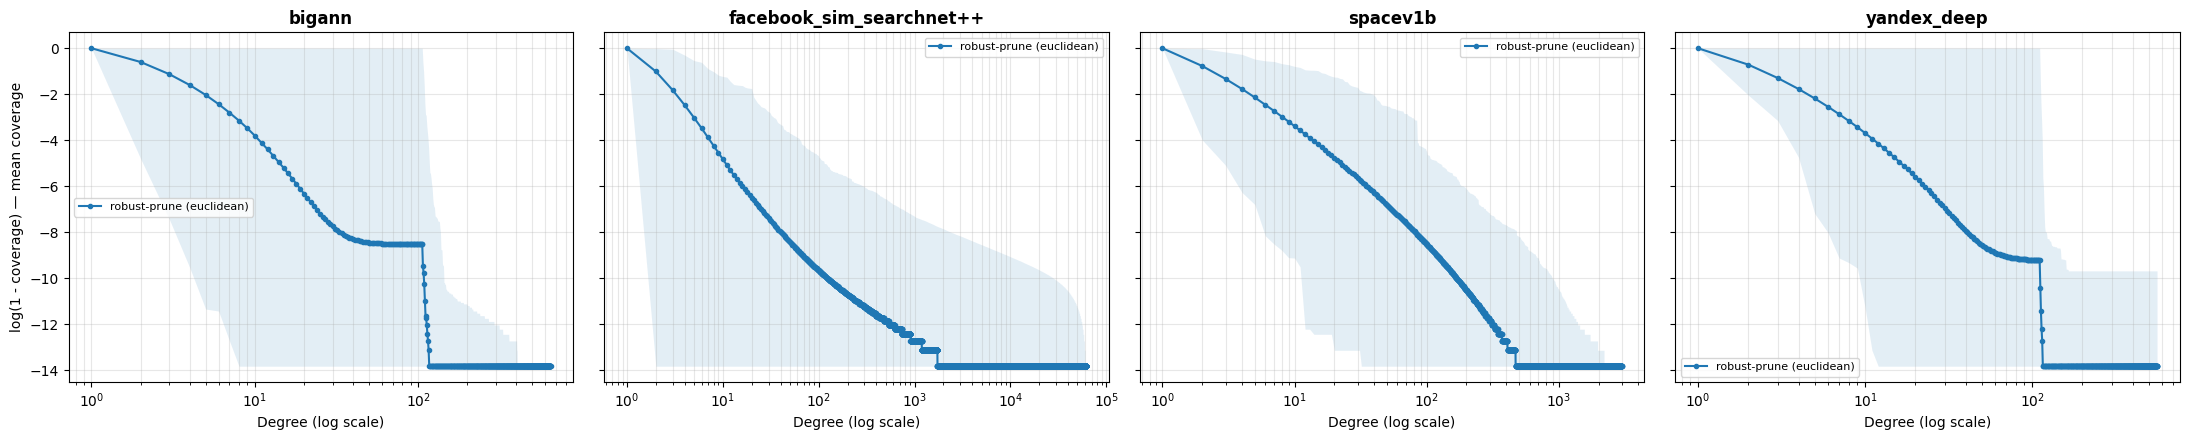

In [8]:
def plot_edges_vs_coverage(df, stat='mean coverage', show_band=True, save_path=None):
    """One subplot per dataset: log(degree) (x) vs log(1 - coverage) (y).

    `edges` is the per-node out-degree, plotted on a log x-axis. Coverage is
    stored as a percentage in [0, 100]; we convert to a fraction and plot
    log(1 - coverage), i.e. the log of the remaining gap to full coverage.
    Values near 100%% coverage map to large-negative y. A separate curve is drawn
    per (metric, method) combination present for the dataset.
    """
    datasets = sorted(df['dataset'].unique())
    n_ds = len(datasets)

    # Floor the uncovered fraction so coverage == 100%% doesn't blow up log().
    EPS = 1e-6

    def log_gap(cov_pct):
        gap = np.clip(1.0 - cov_pct / 100.0, EPS, None)
        return np.log(gap)

    fig, axes = plt.subplots(
        1, n_ds, figsize=(5.5 * n_ds, 4.5), squeeze=False, sharey=True
    )

    for c, dataset in enumerate(datasets):
        ax = axes[0, c]
        sub = df[df['dataset'] == dataset]

        for (metric, method), grp in sub.groupby(['metric', 'method']):
            grp = grp.sort_values('edges')
            label = f"{method}" + (f" ({metric})" if str(metric) not in ('', 'nan') else "")
            line, = ax.plot(grp['edges'], log_gap(grp[stat]), marker='o', markersize=3, label=label)
            if show_band:
                # Note: min coverage -> upper gap, max coverage -> lower gap.
                ax.fill_between(
                    grp['edges'], log_gap(grp['min coverage']), log_gap(grp['max coverage']),
                    color=line.get_color(), alpha=0.12, linewidth=0,
                )

        ax.set_title(dataset, fontweight='bold')
        ax.set_xscale('log')
        ax.set_xlabel('Degree (log scale)')
        if c == 0:
            ax.set_ylabel(f'log(1 - coverage) — {stat}')
        ax.grid(True, alpha=0.3, which='both')
        ax.legend(fontsize=8)

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved -> {save_path}")
    plt.show()


plot_edges_vs_coverage(df, stat='mean coverage', show_band=True)

In [ ]:
# Single-axes overlay: every dataset on one plot, log(degree) vs log(1 - mean coverage).
EPS = 1e-6

fig, ax = plt.subplots(figsize=(7, 5))
for (dataset, method), grp in df.groupby(['dataset', 'method']):
    grp = grp.sort_values('edges')
    gap = np.clip(1.0 - grp['mean coverage'] / 100.0, EPS, None)
    ax.plot(grp['edges'], np.log(gap), marker='o', markersize=3,
            label=f"{dataset} / {method}")

ax.set_xscale('log')
ax.set_xlabel('Degree (log scale)')
ax.set_ylabel('log(1 - mean coverage)')
ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=8)
ax.set_title('log(degree) vs. log(1 - coverage)')
fig.tight_layout()
plt.show()